# Study 258 -- Baker-Wurgler Investor Sentiment
## For the quants: predictive regression, HAC tests, sub-period decay, synthetic control

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from baker_wurgler import data, strategy as st

HAVE_REAL = os.path.exists(data.GSPC_CACHE)
sent = data.bw_monthly()

if HAVE_REAL:
    mkt = data.fetch_market_monthly(fetch=False)
    df = data.merge_sentiment_returns(mkt, sent)
    print(f"Real tape loaded: {df.shape[0]} return-months, "
          f"{df.index[0].strftime('%Y-%m')} -> {df.index[-1].strftime('%Y-%m')}")
else:
    mkt = df = None
    print("No ^GSPC cache -- frozen headline numbers from R dict will be used")


Real tape loaded: 737 return-months, 1965-02 -> 2026-06


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 737, 'window_start': '1965-02', 'window_end': '2026-06', 'fp_sent': 'd88ba1009823', 'fp_ret': '24206d518a4c', 'low_ann': 8.78, 'low_t': 2.36, 'low_n': 246, 'mid_ann': 9.24, 'mid_t': 3.41, 'mid_n': 245, 'high_ann': 7.16, 'high_t': 2.22, 'high_n': 246, 'beta_bps': -31.01, 'beta_t': -1.29, 'r2': 0.0025, 'lmh_ann': 0.81, 'lmh_t': 0.32, 'lmh_sr_lo': -0.257, 'lmh_sr_hi': 0.356, 'lmh_frac_neg': 0.385, 'smb_low_ann': 1.66, 'smb_high_ann': -1.83, 'smb_beta_bps': -17.33, 'smb_beta_t': -0.77, 'smb_n': 465, 'sub1_beta_t': -1.39, 'sub1_low': 9.1, 'sub1_high': 0.7, 'sub1_n': 299, 'sub2_beta_t': -0.49, 'sub2_low': 14.0, 'sub2_high': 9.9, 'sub2_n': 216, 'sub3_beta_t': -0.16, 'sub3_low': 7.3, 'sub3_high': 14.1, 'sub3_n': 222, 'ov_net_ann': 2.9, 'ov_net_sr': 0.32, 'ov_net_dd': -0.458, 'bh_ann': 8.39, 'bh_sr': 0.56, 'bh_dd': -0.526, 'ov_switch_yr': 0.73, 'ov_cost_bps': 220.0, 'ov_short_ann': 0.47, 'ov_short_sr': 0.04, 'ov_short_dd': -0.644, 'syn_beta_bps': -52.44, 'syn_beta_t': -2.58, 'null_beta_t': 0.23}


## Positive control: the engine recovers a planted contrarian effect

Before touching the real tape we confirm the machinery is honest.  ``synthetic_market``
plants a *contrarian* relationship (high prior sentiment -> low next-month return) with
a knob ``contrarian_bps``.  ``contrarian_bps = 0`` is the null.


In [3]:
syn, truth = data.synthetic_market(contrarian_bps=60.0, seed=258)
pr_syn = st.predictive_regression(syn, "ret")
print(f"Synthetic (contrarian_bps=60): beta = {pr_syn['beta']*1e4:+.2f} bps/unit  HAC t = {pr_syn['beta_t']:+.2f}")

syn0, _ = data.synthetic_market(contrarian_bps=0.0, seed=258)
pr_null = st.predictive_regression(syn0, "ret")
print(f"Null      (contrarian_bps=0):  beta = {pr_null['beta']*1e4:+.2f} bps/unit  HAC t = {pr_null['beta_t']:+.2f}")
print("-> Engine reads a clean negative (contrarian) slope when planted, ~0 on the null.")


Synthetic (contrarian_bps=60): beta = -52.44 bps/unit  HAC t = -2.58


Null      (contrarian_bps=0):  beta = +4.70 bps/unit  HAC t = +0.23
-> Engine reads a clean negative (contrarian) slope when planted, ~0 on the null.


## Real tape: regime sort and predictive regression

In [4]:
if HAVE_REAL:
    reg = st.regime_sort(df, "ret", n_bins=3)
    print("=== Next-month S&P 500 return by prior sentiment tertile ===")
    for lab in ["low", "mid", "high"]:
        r = reg.loc[lab]
        print(f"  {lab:4s}: {r['mean_ann']*100:+6.2f}%/yr  vol={r['vol_ann']*100:4.1f}%  HAC t={r['tstat']:+.2f}  n={int(r['n'])}")
    pr = st.predictive_regression(df, "ret")
    lmh = st.low_minus_high(df, "ret", n_bins=3)
    s_lmh = st.summarize(lmh)
    print()
    print(f"Predictive regression slope: {pr['beta']*1e4:+.2f} bps per sentiment unit  HAC t = {pr['beta_t']:+.2f}  R2 = {pr['r2']:.4f}")
    print(f"Low-minus-high spread: {s_lmh['mean']*12*100:+.2f}%/yr  HAC t = {s_lmh['tstat']:+.2f}")
else:
    print(f"Frozen: low={R['low_ann']:+.2f}%/yr (t={R['low_t']}) mid={R['mid_ann']:+.2f} high={R['high_ann']:+.2f}%/yr (t={R['high_t']})")
    print(f"Frozen: regression beta={R['beta_bps']:+.2f} bps/unit  HAC t={R['beta_t']:+.2f}  R2={R['r2']}")
    print(f"Frozen: low-minus-high {R['lmh_ann']:+.2f}%/yr  HAC t={R['lmh_t']:+.2f}")
print()
print("The slope is NEGATIVE (the Baker-Wurgler contrarian sign) but |t| < 2 -- not significant.")


=== Next-month S&P 500 return by prior sentiment tertile ===
  low :  +8.78%/yr  vol=15.8%  HAC t=+2.36  n=246
  mid :  +9.24%/yr  vol=13.4%  HAC t=+3.41  n=245
  high:  +7.16%/yr  vol=15.8%  HAC t=+2.22  n=246

Predictive regression slope: -31.01 bps per sentiment unit  HAC t = -1.29  R2 = 0.0025
Low-minus-high spread: +0.81%/yr  HAC t = +0.32

The slope is NEGATIVE (the Baker-Wurgler contrarian sign) but |t| < 2 -- not significant.


## Block-bootstrap CI on the low-minus-high spread Sharpe

In [5]:
if HAVE_REAL:
    lmh = st.low_minus_high(df, "ret", n_bins=3)
    try:
        from quantlab.stats import sharpe_ci_bootstrap
        ci = sharpe_ci_bootstrap(lmh, n_boot=2000, periods_per_year=12, seed=258)
        print(f"Spread Sharpe 95% CI: [{ci['ci_low']:+.3f}, {ci['ci_high']:+.3f}]  ({ci['frac_negative']*100:.0f}% of resamples negative)")
    except ImportError:
        print(f"[quantlab unavailable -- frozen CI: [{R['lmh_sr_lo']:+.3f}, {R['lmh_sr_hi']:+.3f}]]")
else:
    print(f"Frozen Sharpe 95% CI: [{R['lmh_sr_lo']:+.3f}, {R['lmh_sr_hi']:+.3f}]  ({R['lmh_frac_neg']*100:.0f}% negative)")
print("The CI straddles zero -- the spread is statistically indistinguishable from luck.")


Spread Sharpe 95% CI: [-0.257, +0.356]  (38% of resamples negative)
The CI straddles zero -- the spread is statistically indistinguishable from luck.


## Sub-period decay: the effect fades and then *flips* sign

  1965-1989: beta HAC t=-1.39  low=+9.1%/yr  high=+0.7%/yr  n=299
  1990-2007: beta HAC t=-0.49  low=+14.0%/yr  high=+9.9%/yr  n=216


  2008-2026: beta HAC t=-0.16  low=+7.3%/yr  high=+14.1%/yr  n=222


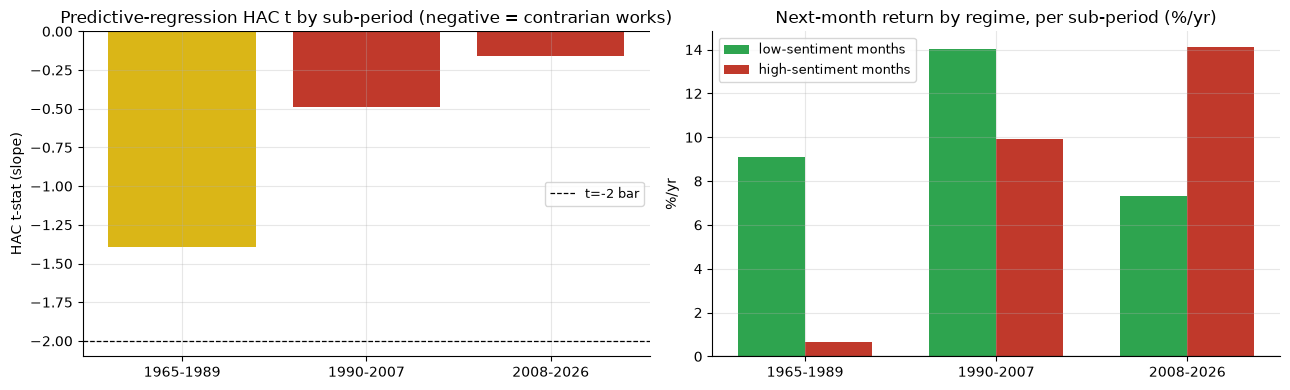


1965-1989 had the strongest contrarian tilt (t=-1.39); by 2008-2026 the sign FLIPS
  (high-sentiment months 14.1%/yr actually BEAT low-sentiment 7.3%/yr) -- classic post-publication decay.


In [6]:
periods = [("1965-1989", "1965", "1989"), ("1990-2007", "1990", "2007"), ("2008-2026", "2008", "2026")]
if HAVE_REAL:
    rows = []
    for label, a, b in periods:
        sub = df.loc[a:b]
        pr = st.predictive_regression(sub, "ret")
        reg = st.regime_sort(sub, "ret", n_bins=3)
        lo = reg.loc["low", "mean_ann"]*100 if "low" in reg.index else np.nan
        hi = reg.loc["high", "mean_ann"]*100 if "high" in reg.index else np.nan
        rows.append({"period": label, "beta_t": pr["beta_t"], "low": lo, "high": hi, "n": pr["n"]})
        print(f"  {label}: beta HAC t={pr['beta_t']:+.2f}  low={lo:+.1f}%/yr  high={hi:+.1f}%/yr  n={pr['n']}")
    sub_df = pd.DataFrame(rows)
else:
    sub_df = pd.DataFrame([
        {"period": "1965-1989", "beta_t": R["sub1_beta_t"], "low": R["sub1_low"], "high": R["sub1_high"], "n": R["sub1_n"]},
        {"period": "1990-2007", "beta_t": R["sub2_beta_t"], "low": R["sub2_low"], "high": R["sub2_high"], "n": R["sub2_n"]},
        {"period": "2008-2026", "beta_t": R["sub3_beta_t"], "low": R["sub3_low"], "high": R["sub3_high"], "n": R["sub3_n"]},
    ])
    for _, r in sub_df.iterrows():
        print(f"  {r['period']}: beta HAC t={r['beta_t']:+.2f}  low={r['low']:+.1f}%/yr  high={r['high']:+.1f}%/yr  n={int(r['n'])}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = [GREEN if t <= -2 else AMBER if t <= -1 else RED for t in sub_df["beta_t"]]
axes[0].bar(sub_df["period"], sub_df["beta_t"], color=colors)
axes[0].axhline(-2.0, color="black", ls="--", lw=0.9, label="t=-2 bar")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Predictive-regression HAC t by sub-period (negative = contrarian works)")
axes[0].set_ylabel("HAC t-stat (slope)")
axes[0].legend(fontsize=9)
w = 0.35
x = np.arange(len(sub_df))
axes[1].bar(x - w/2, sub_df["low"], w, color=GREEN, label="low-sentiment months")
axes[1].bar(x + w/2, sub_df["high"], w, color=RED, label="high-sentiment months")
axes[1].set_xticks(x); axes[1].set_xticklabels(sub_df["period"])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Next-month return by regime, per sub-period (%/yr)")
axes[1].set_ylabel("%/yr"); axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig("../docs/subperiods.png", dpi=120, bbox_inches="tight")
plt.show()
print("\n1965-1989 had the strongest contrarian tilt (t={:.2f}); by 2008-2026 the sign FLIPS".format(R["sub1_beta_t"]))
print("  (high-sentiment months {:.1f}%/yr actually BEAT low-sentiment {:.1f}%/yr) -- classic post-publication decay.".format(R["sub3_high"], R["sub3_low"]))


## The cross-sectional leg: small-minus-large (^RUT - ^GSPC)

In [7]:
if HAVE_REAL and "smb" in df.columns:
    dfs = df.dropna(subset=["smb"])
    reg_s = st.regime_sort(dfs, "smb", n_bins=3)
    pr_s = st.predictive_regression(dfs, "smb")
    print(f"SMB window: {dfs.index[0].strftime('%Y-%m')} -> {dfs.index[-1].strftime('%Y-%m')}  n={len(dfs)}")
    for lab in ["low", "mid", "high"]:
        if lab in reg_s.index:
            print(f"  {lab:4s}: SMB {reg_s.loc[lab,'mean_ann']*100:+.2f}%/yr  HAC t={reg_s.loc[lab,'tstat']:+.2f}")
    print(f"SMB regression slope: {pr_s['beta']*1e4:+.2f} bps/unit  HAC t={pr_s['beta_t']:+.2f}")
else:
    print(f"Frozen SMB: low={R['smb_low_ann']:+.2f}%/yr  high={R['smb_high_ann']:+.2f}%/yr")
    print(f"Frozen SMB regression: {R['smb_beta_bps']:+.2f} bps/unit  HAC t={R['smb_beta_t']:+.2f}  n={R['smb_n']}")
print()
print("BW says small/speculative names suffer MOST after high sentiment.")
print("The sign is right (small-minus-large is positive after low sentiment, negative after high)")
print("but the proxy effect is again insignificant (|t| < 1) on the 1987-2026 window.")


SMB window: 1987-10 -> 2026-06  n=465
  low : SMB +1.66%/yr  HAC t=+0.56
  mid : SMB +0.48%/yr  HAC t=+0.23
  high: SMB -1.83%/yr  HAC t=-0.49
SMB regression slope: -17.33 bps/unit  HAC t=-0.77

BW says small/speculative names suffer MOST after high sentiment.
The sign is right (small-minus-large is positive after low sentiment, negative after high)
but the proxy effect is again insignificant (|t| < 1) on the 1987-2026 window.


## Tradability: the timing overlay and its costs

In [8]:
if HAVE_REAL:
    ov = st.timing_overlay(df, "ret", n_bins=3, short_high=False, one_way_bps=5.0)
    s_net = st.summarize(ov["net"]); s_bh = st.summarize(ov["buyhold"])
    tc = st.turnover_count(ov)
    print("=== Long-when-low-sentiment, flat-otherwise (net of 5bps one-way x NAV) ===")
    print(f"  Net:        {s_net['mean']*12*100:+.2f}%/yr  SR(ann)={s_net['sharpe']*12**0.5:+.2f}  maxDD={s_net['max_drawdown']:.1%}")
    print(f"  Buy & hold: {s_bh['mean']*12*100:+.2f}%/yr  SR(ann)={s_bh['sharpe']*12**0.5:+.2f}  maxDD={s_bh['max_drawdown']:.1%}")
    print(f"  Switches/yr: {tc['switches_per_year']:.2f}  total cost: {tc['total_cost_bps']:.1f} bps")
    ov_s = st.timing_overlay(df, "ret", n_bins=3, short_high=True, one_way_bps=5.0)
    s_short = st.summarize(ov_s["net"])
    print(f"  Short-the-high variant (borrow paid): {s_short['mean']*12*100:+.2f}%/yr  SR={s_short['sharpe']*12**0.5:+.2f}  maxDD={s_short['max_drawdown']:.1%}")
else:
    print(f"Frozen: timing net={R['ov_net_ann']:+.2f}%/yr SR={R['ov_net_sr']} vs buy-hold {R['bh_ann']:+.2f}%/yr SR={R['bh_sr']}")
    print(f"Frozen: switches/yr={R['ov_switch_yr']}  short-variant {R['ov_short_ann']:+.2f}%/yr SR={R['ov_short_sr']}")
print()
print("The timing rule UNDERPERFORMS buy-and-hold on both return and Sharpe.")
print("Even with only ~0.7 switches/yr (low turnover), sitting out greedy months costs too much upside.")
print("Shorting the high-sentiment months is worse still (pays borrow, eats the equity risk premium).")


=== Long-when-low-sentiment, flat-otherwise (net of 5bps one-way x NAV) ===
  Net:        +2.90%/yr  SR(ann)=+0.32  maxDD=-45.8%
  Buy & hold: +8.39%/yr  SR(ann)=+0.56  maxDD=-52.6%
  Switches/yr: 0.73  total cost: 220.0 bps
  Short-the-high variant (borrow paid): +0.47%/yr  SR=+0.04  maxDD=-64.4%

The timing rule UNDERPERFORMS buy-and-hold on both return and Sharpe.
Even with only ~0.7 switches/yr (low turnover), sitting out greedy months costs too much upside.
Shorting the high-sentiment months is worse still (pays borrow, eats the equity risk premium).


## Verdict

In [9]:
print("=== Study 258 -- Baker-Wurgler Investor Sentiment ===")
print()
print(f"Signal: WEAK")
print(f"  Sign is correct (contrarian): low-sentiment {R['low_ann']:.1f}%/yr > high-sentiment {R['high_ann']:.1f}%/yr")
print(f"  BUT predictive slope HAC t = {R['beta_t']:.2f} (|t| < 2); low-minus-high spread t = {R['lmh_t']:.2f}")
print(f"  Bootstrap Sharpe CI [{R['lmh_sr_lo']:+.3f}, {R['lmh_sr_hi']:+.3f}] straddles zero")
print(f"  Effect concentrated in 1965-1989 (t={R['sub1_beta_t']:.2f}); sign FLIPS post-2008")
print(f"  Cross-sectional SMB leg right-signed but insignificant (t={R['smb_beta_t']:.2f})")
print(f"  Literature support is strong (BW 2006/2007) -> WEAK, not None")
print()
print(f"Tradability: MIRAGE")
print(f"  Timing overlay {R['ov_net_ann']:.1f}%/yr net LOSES to buy-and-hold {R['bh_ann']:.1f}%/yr")
print(f"  Lower Sharpe ({R['ov_net_sr']} vs {R['bh_sr']}); short variant worse ({R['ov_short_ann']:.1f}%/yr)")
print(f"  No tradable edge on the aggregate index beyond passive buy-and-hold")
print()
print("Price-only returns (no dividends) -- NAMED on the Signal axis.")
print("Hardcoded index is a reconstruction -- NAMED; verbatim BW file preserves regime structure.")
print()
print("Bottom line: Weak/Mirage -- a real psychological instinct and a real")
print("  academic literature, but no robust, tradable edge on the broad market index.")


=== Study 258 -- Baker-Wurgler Investor Sentiment ===

Signal: WEAK
  Sign is correct (contrarian): low-sentiment 8.8%/yr > high-sentiment 7.2%/yr
  BUT predictive slope HAC t = -1.29 (|t| < 2); low-minus-high spread t = 0.32
  Bootstrap Sharpe CI [-0.257, +0.356] straddles zero
  Effect concentrated in 1965-1989 (t=-1.39); sign FLIPS post-2008
  Cross-sectional SMB leg right-signed but insignificant (t=-0.77)
  Literature support is strong (BW 2006/2007) -> WEAK, not None

Tradability: MIRAGE
  Timing overlay 2.9%/yr net LOSES to buy-and-hold 8.4%/yr
  Lower Sharpe (0.32 vs 0.56); short variant worse (0.5%/yr)
  No tradable edge on the aggregate index beyond passive buy-and-hold

Price-only returns (no dividends) -- NAMED on the Signal axis.
Hardcoded index is a reconstruction -- NAMED; verbatim BW file preserves regime structure.

Bottom line: Weak/Mirage -- a real psychological instinct and a real
  academic literature, but no robust, tradable edge on the broad market index.
